In [4]:
# =============================================================================
# MO_WAT Scene – System-Level Simulation with PFSchedulerSUMIMO
# Plots: SINR, MCS, Throughput, PRB Allocation
# Based on: v5_MO_WAT_new_scene_SYS_v2.ipynb + Louhans_sys_meets_rt_docs_tp.ipynb
# v4: num_slots and NUM_UE derived automatically from SUMO trace content
#     (pre-scan → presence filter → dynamic sizing)
# =============================================================================

# -----------------------------------------------------------------------------
# Environment setup (must be BEFORE TensorFlow import)
# -----------------------------------------------------------------------------
import os
import platform
import xml.etree.ElementTree as ET

import numpy as np

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

is_wsl = (platform.system() == 'Linux' and 'microsoft' in platform.release().lower())
if is_wsl:
    wsl_lib_path = '/usr/lib/wsl/lib'
    if os.path.exists(wsl_lib_path):
        current_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
        if wsl_lib_path not in current_ld_path:
            os.environ['LD_LIBRARY_PATH'] = (
                f"{wsl_lib_path}:{current_ld_path}" if current_ld_path else wsl_lib_path
            )

# -----------------------------------------------------------------------------
# TensorFlow initialization
# -----------------------------------------------------------------------------
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
gpu_available = len(gpus) > 0

if gpu_available:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"TensorFlow GPU found: {gpus[0].name}")
    except RuntimeError as e:
        print("Error setting memory growth:", e)
else:
    print("No GPU found, falling back to CPU")
    if is_wsl:
        print("-" * 60)
        print("TIP: You are running in WSL and no GPU was found.")
        print("-" * 60)
    os.environ['CUDA_VISIBLE_DEVICES'] = ''

# -----------------------------------------------------------------------------
# Mitsuba initialization (must match TF device)
# -----------------------------------------------------------------------------
import mitsuba as mi

if gpu_available:
    try:
        mi.set_variant('cuda_ad_mono_polarized')
        print(f"Mitsuba variant set to: {mi.variant()}")
    except Exception:
        print("CUDA variant not available for Mitsuba. Falling back to LLVM.")
        mi.set_variant('llvm_ad_mono_polarized')
        print(f"Mitsuba variant set to: {mi.variant()}")
else:
    mi.set_variant('llvm_ad_mono_polarized')
    print(f"Mitsuba variant set to: {mi.variant()}")

# -----------------------------------------------------------------------------
# Standard imports
# -----------------------------------------------------------------------------
import drjit as dr
import torch

torch.cuda.is_available = lambda: False
torch.set_default_device('cpu')

import matplotlib.pyplot as plt

from sionna.rt import (
    load_scene, Transmitter, Receiver, PlanarArray,
    RadioMapSolver, PathSolver, subcarrier_frequencies, Camera, transform_mesh
)
from sionna.phy import config
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, RZFPrecodedChannel, LMMSEPostEqualizationSINR
from sionna.phy.constants import BOLTZMANN_CONSTANT
from sionna.phy.nr.utils import decode_mcs_index
from sionna.phy.utils import dbm_to_watt
from sionna.sys import (
    PHYAbstraction, OuterLoopLinkAdaptation,
    PFSchedulerSUMIMO, downlink_fair_power_control
)
from sionna.sys.utils import spread_across_subcarriers


def log2(x):
    """log base-2 via natural log (not exported by sionna.phy.utils in this version)."""
    return tf.math.log(tf.cast(x, tf.float32)) / tf.math.log(tf.constant(2.0, dtype=tf.float32))


# -----------------------------------------------------------------------------
# Sionna configuration
# -----------------------------------------------------------------------------
config.precision = 'single'
config.seed = 48

# =============================================================================
# Simulation parameters  (MO_WAT cell config)
# =============================================================================

# num_slots and NUM_UE are derived from the SUMO trace — see SUMO section below.
# Optional hard caps (set to None to use all data from the trace):
MAX_SLOTS = None   # e.g. 500 to limit run length; None = all timesteps
MAX_UE    = None   # e.g. 20 to cap UE count;    None = all eligible vehicles

# Time/frequency resource grid – n78, 100 MHz, 30 kHz SCS
carrier_frequency    = 3.5e9
num_prbs             = 273
subcarriers_per_prb  = 12
num_subcarriers      = num_prbs * subcarriers_per_prb   # 3276
subcarrier_spacing   = 30e3
num_ofdm_symbols     = 12

# Environment temperature
temperature = 294   # [K]

# BLER target
bler_target = 0.1

# MCS table
mcs_table_index = 1

# Base station transmit power (MO_WAT: 25 dBm per sector)
bs_power_dbm  = 25
bs_power_watt = dbm_to_watt(bs_power_dbm)

# Thermal noise power per subcarrier
no = BOLTZMANN_CONSTANT * temperature * subcarrier_spacing

print(f"Total subcarriers : {num_subcarriers}")
print(f"Total PRBs        : {num_prbs}")
print(f"BS TX power       : {bs_power_dbm} dBm  ({bs_power_watt:.4f} W)")

# =============================================================================
# Scene setup – MO_WAT topology
# =============================================================================
dr.flush_malloc_cache()

scene = load_scene("../scenes/MO_v5/MO_v5_converted.xml")
scene.frequency = carrier_frequency
scene.bandwidth = num_subcarriers * subcarrier_spacing


def normalize_radio_materials(scene):
    """Reassign scene objects to known-good Sionna radio materials."""
    radio_materials = getattr(scene, "radio_materials", {})
    if not radio_materials:
        return
    fallback_name = "itu_concrete" if "itu_concrete" in radio_materials else next(iter(radio_materials))
    brick_name = "itu_brick"  if "itu_brick"  in radio_materials else fallback_name
    glass_name = "itu_glass"  if "itu_glass"  in radio_materials else fallback_name
    metal_name = "itu_metal"  if "itu_metal"  in radio_materials else fallback_name

    for obj_name, obj in getattr(scene, "objects", {}).items():
        name = obj_name.lower()
        if "brick"  in name:
            target = brick_name
        elif "glass" in name or "window" in name:
            target = glass_name
        elif "metal" in name or "steel" in name or "roof" in name:
            target = metal_name
        else:
            target = fallback_name
        try:
            obj.radio_material = radio_materials[target]
        except Exception:
            try:
                obj.radio_material = target
            except Exception:
                pass


normalize_radio_materials(scene)

# ------------------------------------------------------------------
# TX antenna array (shared by all sectors)
# ------------------------------------------------------------------
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="cross"
)

# RX antenna array
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

# ------------------------------------------------------------------
# Transmitters – MO_WAT cell topology
# ------------------------------------------------------------------
for name in list(scene.transmitters):
    scene.remove(name)

sites = [
    # Jerozolimskie 156 - Renault (gnodeb_id 5633)
    {
        "name":      "site_5633",
        "position":  [-501, 344, 18 + 12.5],
        "downtilt":  -6,
        "azimuths":  [309, 189, 80],
        "power_dbm": 25,
    },
    # Al. Jerozolimskie 181 - Adgar Park West (gnodeb_id 81088)
    {
        "name":      "site_81088",
        "position":  [-211, 345, 31.7 + 15],
        "downtilt":  -6.0,
        "azimuths":  [310, 190, 70],
        "power_dbm": 25,
    },
    # al. Bohaterów Września 3 (gnodeb_id 22343)
    {
        "name":      "site_22343",
        "position":  [425, 355, 25.2 + 8],
        "downtilt":  -6.0,
        "azimuths":  [170, 257, 30],
        "power_dbm": 25,
    },
    # ul. Włodarzewska 69 (gnodeb_id 14146)
    {
        "name":      "site_14146",
        "position":  [-201, -542, 20 + 10],
        "downtilt":  -6.0,
        "azimuths":  [309, 189, 69],
        "power_dbm": 25,
    },
]

for site in sites:
    for i, az in enumerate(site["azimuths"]):
        tx = Transmitter(
            name=f"{site['name']}_sector_{i + 1}",
            position=mi.Point3f(np.array(site["position"], dtype=np.float32)),
            orientation=mi.Point3f(np.array(
                [np.deg2rad(az), np.deg2rad(site["downtilt"]), 0.0],
                dtype=np.float32
            )),
            power_dbm=site["power_dbm"],
            display_radius=25,
            color=[138 / 255, 43 / 255, 226 / 255],
        )
        scene.add(tx)

print(f"Transmitters added: {list(scene.transmitters.keys())}")

# =============================================================================
# UE positions – SUMO FCD trace
# =============================================================================

def scan_sumo_trace(file_path: str) -> tuple[int, int]:
    """
    Quick single-pass scan of a SUMO FCD XML file.

    Returns
    -------
    total_timesteps : int  – number of <timestep> elements in the file
    total_vehicles  : int  – number of unique vehicle IDs across all timesteps
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"SUMO trace not found: {file_path}")

    seen_vehicles: set[str] = set()
    total_timesteps = 0

    # Iterparse avoids loading the whole XML into memory
    for event, elem in ET.iterparse(file_path, events=("end",)):
        if elem.tag == "vehicle":
            seen_vehicles.add(elem.get("id"))
            elem.clear()
        elif elem.tag == "timestep":
            total_timesteps += 1
            elem.clear()

    return total_timesteps, len(seen_vehicles)


def load_sumo_trace(
    file_path: str,
    x_offset: float = 0.0,
    y_offset: float = 0.0,
    z_offset: float = 1.5,
    *,
    max_slots:             int   | None = None,
    max_ue:                int   | None = None,
    min_presence_fraction: float = 0.10,
    teleport_threshold_m:  float = 50.0,
    forward_fill:          bool  = True,
    max_fill_gap:          int   = 5,
) -> tuple[np.ndarray, list[str], np.ndarray]:
    """
    Parse a SUMO FCD XML trace and return aligned, cleaned UE positions.

    Parameters
    ----------
    file_path             : path to the SUMO FCD XML file
    x_offset, y_offset    : coordinate offsets  (SUMO → Sionna scene)
    z_offset              : base receiver height (terrain + UE antenna height)
    max_slots             : cap on timesteps loaded; None = all in file
    max_ue                : cap on UEs selected;    None = all eligible vehicles
    min_presence_fraction : UE must appear in at least this fraction of loaded
                            slots to be eligible (removes drive-through vehicles)
    teleport_threshold_m  : jump > this value (m, consecutive slots) → blanked
    forward_fill          : fill short NaN gaps with last known position
    max_fill_gap          : only fill gaps up to this many consecutive slots

    Returns
    -------
    positions   : float32 [num_slots, num_ue, 3]  – NaN where absent
    vehicle_ids : list[str]  len == num_ue
    valid_mask  : bool   [num_slots, num_ue]       – True where position is real
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"SUMO trace not found: {file_path}")

    tree      = ET.parse(file_path)
    root      = tree.getroot()
    all_ts    = root.findall("timestep")
    timesteps = all_ts if max_slots is None else all_ts[:max_slots]
    actual_slots = len(timesteps)

    print(f"[SUMO] Loading {actual_slots} timesteps"
          + (f" (capped from {len(all_ts)})" if max_slots and len(all_ts) > max_slots else ""))

    # ---- single pass: collect positions and per-vehicle slot index lists ----
    vehicle_slots: dict[str, list[int]] = {}
    raw: dict[tuple[str, int], tuple[float, float, float]] = {}

    for t_idx, ts in enumerate(timesteps):
        for v in ts.findall("vehicle"):
            vid = v.get("id")
            x   = float(v.get("x")) + x_offset
            y   = float(v.get("y")) + y_offset
            z   = z_offset + (float(v.get("z")) if v.get("z") else 0.0)
            vehicle_slots.setdefault(vid, []).append(t_idx)
            raw[(vid, t_idx)] = (x, y, z)

    # ---- rank by presence, apply threshold, apply optional UE cap -----------
    ranked = sorted(vehicle_slots.items(), key=lambda kv: -len(kv[1]))
    min_slots_required = max(1, int(min_presence_fraction * actual_slots))
    eligible = [(vid, slots) for vid, slots in ranked if len(slots) >= min_slots_required]

    n_eligible = len(eligible)
    selected   = [vid for vid, _ in (eligible if max_ue is None else eligible[:max_ue])]
    n_selected = len(selected)

    print(f"[SUMO] Vehicles in trace: {len(vehicle_slots)} total  |  "
          f"{n_eligible} pass ≥{min_presence_fraction*100:.0f}% presence  |  "
          f"{n_selected} selected")

    if n_selected == 0:
        raise RuntimeError(
            "[SUMO] No vehicles passed the presence filter. "
            "Lower min_presence_fraction or check the trace file."
        )

    # ---- build position array -----------------------------------------------
    positions = np.full((actual_slots, n_selected, 3), np.nan, dtype=np.float32)

    for ue_idx, vid in enumerate(selected):
        for t_idx in vehicle_slots[vid]:
            positions[t_idx, ue_idx] = raw[(vid, t_idx)]

    # ---- teleport suppression -----------------------------------------------
    for ue_idx in range(n_selected):
        valid_t = np.where(~np.isnan(positions[:, ue_idx, 0]))[0]
        for i in range(1, len(valid_t)):
            t_prev, t_cur = valid_t[i - 1], valid_t[i]
            if t_cur - t_prev == 1:
                delta = np.linalg.norm(
                    positions[t_cur, ue_idx] - positions[t_prev, ue_idx]
                )
                if delta > teleport_threshold_m:
                    positions[t_cur, ue_idx] = np.nan

    # ---- forward-fill short gaps --------------------------------------------
    if forward_fill:
        for ue_idx in range(n_selected):
            last_valid_t: int | None = None
            gap_len = 0
            for t in range(actual_slots):
                if not np.isnan(positions[t, ue_idx, 0]):
                    last_valid_t = t
                    gap_len      = 0
                else:
                    if last_valid_t is not None and gap_len <= max_fill_gap:
                        positions[t, ue_idx] = positions[last_valid_t, ue_idx]
                    gap_len += 1

    valid_mask = ~np.isnan(positions[..., 0])

    # ---- per-UE summary -----------------------------------------------------
    presence_pct = valid_mask.mean(axis=0) * 100
    print("[SUMO] Selected vehicles and slot presence:")
    for i, vid in enumerate(selected):
        print(f"  UE{i:02d}  {vid:30s}  {presence_pct[i]:.1f}%")

    return positions, selected, valid_mask


# =============================================================================
# SUMO trace – locate, pre-scan, load
# =============================================================================

sumo_trace_path = "../sumoTrace_v4.xml"
for candidate in [
    "./sumoTrace_v4.xml",
    "./Kamil/Demo/sumoTrace_v4.xml",
    "../../Kamil/Demo/sumoTrace_v4.xml",
]:
    if os.path.exists(candidate):
        sumo_trace_path = candidate
        break

# -- pre-scan: report trace dimensions before committing to a full load -------
_total_slots, _total_vehicles = scan_sumo_trace(sumo_trace_path)
print(f"[SUMO] Trace summary: {_total_slots} timesteps, {_total_vehicles} unique vehicles")

# Coordinate offset:  sionna_coord = sumo_coord + offset
# Reference: Sionna (-515, 287)  ↔  SUMO (901, 1435)  → (-1416, -1148)
sumo_x_offset = -1416.0
sumo_y_offset = -1148.0
sumo_z_offset =    8.5   # 7.0 m terrain elevation + 1.5 m receiver height

# -- full load: num_slots and NUM_UE come entirely from the trace --------------
ut_positions, ut_ids, ut_valid = load_sumo_trace(
    sumo_trace_path,
    x_offset=sumo_x_offset,
    y_offset=sumo_y_offset,
    z_offset=sumo_z_offset,
    max_slots=MAX_SLOTS,               # None → all timesteps in file
    max_ue=MAX_UE,                     # None → all eligible vehicles
    min_presence_fraction=0.10,
    teleport_threshold_m=50.0,
    forward_fill=True,
    max_fill_gap=5,
)

# -- simulation dimensions now come from the trace, not hardcoded values ------
num_ut    = len(ut_ids)       # actual UEs that passed the presence filter
num_slots = ut_positions.shape[0]   # actual timesteps loaded
num_bs    = len(scene.transmitters)

print(f"\nSimulation dimensions (from SUMO trace):")
print(f"  Slots : {num_slots}")
print(f"  UEs   : {num_ut}")
print(f"  BSs   : {num_bs}")

# Sanity-check: coordinate range
if np.any(ut_valid):
    valid_pos = ut_positions[ut_valid]
    print("Transformed UE coordinate range (valid positions only):")
    for axis, label in enumerate(["X", "Y", "Z"]):
        print(f"  {label}: {valid_pos[:, axis].min():.1f} to {valid_pos[:, axis].max():.1f}")
else:
    print("⚠  No valid UE positions found — check SUMO file path and coordinate offsets.")

# =============================================================================
# Receiver setup  –  one persistent receiver per UE, moved each slot
# =============================================================================
# Adding num_slots × num_ue receivers simultaneously is wrong for path
# animation: PathSolver would see every UE at every position at once.
# Instead we keep one Receiver object per UE and relocate it each slot.

for rx_name in list(scene.receivers):
    scene.remove(rx_name)

ue_colors            = [list(np.random.rand(3)) for _ in range(num_ut)]
_ue_receiver_names: list[str] = []

for ue_idx in range(num_ut):
    # Seed with first valid position (required by Sionna at add-time)
    first_valid_slot = int(ut_valid[:, ue_idx].argmax())
    rx = Receiver(
        name=f"ue_{ue_idx}",
        position=ut_positions[first_valid_slot, ue_idx],
        display_radius=15,
        color=ue_colors[ue_idx],
    )
    scene.add(rx)
    _ue_receiver_names.append(f"ue_{ue_idx}")

print(f"Persistent receivers added: {_ue_receiver_names}")

_OFF_SCENE = np.array([0.0, 0.0, -9999.0], dtype=np.float32)   # underground


def set_ue_positions_for_slot(slot: int) -> list[str]:
    """
    Relocate each UE receiver to its position for *slot*.

    UEs absent from this slot are moved underground so PathSolver ignores
    them without the cost of remove() / add() each iteration.

    Returns the list of receiver names that are active in this slot
    (to be passed to PathSolver or the system-level abstraction).
    """
    active: list[str] = []
    for ue_idx, rx_name in enumerate(_ue_receiver_names):
        rx = scene.receivers[rx_name]
        if ut_valid[slot, ue_idx]:
            rx.position = ut_positions[slot, ue_idx]
            active.append(rx_name)
        else:
            rx.position = _OFF_SCENE
    return active


TensorFlow GPU found: /physical_device:GPU:0
Mitsuba variant set to: cuda_ad_mono_polarized
Total subcarriers : 3276
Total PRBs        : 273
BS TX power       : 25 dBm  (0.3162 W)
2026-06-08 09:44:57 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Transmitters added: ['site_5633_sector_1', 'site_5633_sector_2', 'site_5633_sector_3', 'site_81088_sector_1', 'site_81088_sector_2', 'site_81088_sector_3', 'site_22343_sector_1', 'site_22343_sector_2', 'site_22343_sector_3', 'site_14146_sector_1', 'site_14146_sector_2', 'site_14146_sector_3']
[SUMO] Trace summary: 4102 timesteps, 647 unique vehicles
[SUMO] Loading 4102 timesteps
[SUMO] Vehicles in trace: 647 total  |  187 pass ≥10% presence  |  187 selected
[SUMO] Selected vehicles and slot presence:
  UE00  veh217                          83.0%
  UE01  veh259                          82.4%
  UE02  veh261                          82.0%
  UE03  veh209                          81.7%
  UE04  ve

Radio map: UEs positioned at slot 2051  (92/187 active)
Trajectory dots added: 11113
Trajectory receivers removed — scene ready for per-slot loop.


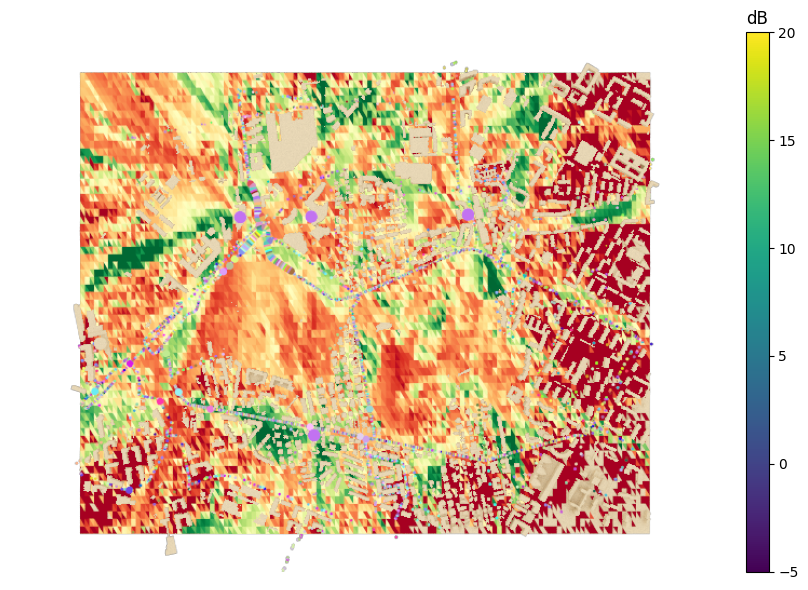

In [5]:
# =============================================================================
# Radio map (SINR overview of the scene)
# =============================================================================

# --- position UEs at a representative slot before rendering ------------------
# Change VISUALIZE_SLOT to any slot index you want, or use the midpoint.
VISUALIZE_SLOT = num_slots // 2
active_at_vis  = set_ue_positions_for_slot(VISUALIZE_SLOT)
print(f"Radio map: UEs positioned at slot {VISUALIZE_SLOT}  "
      f"({len(active_at_vis)}/{num_ut} active)")

# --- optionally overlay full UE trajectories as ghost receivers --------------
# Adds a lightweight dot for every valid (slot, UE) position so the radio map
# render shows the full path each vehicle took across the scene.
# Set SHOW_TRAJECTORIES = False to skip this (faster scene.render call).
SHOW_TRAJECTORIES = True

_traj_rx_names: list[str] = []
if SHOW_TRAJECTORIES:
    # subsample every N slots to keep dot count manageable
    TRAJECTORY_STEP = max(1, num_slots // 200)   # ~200 dots per UE max
    for ue_idx in range(num_ut):
        color = ue_colors[ue_idx]
        for slot in range(0, num_slots, TRAJECTORY_STEP):
            if ut_valid[slot, ue_idx]:
                traj_name = f"_traj_ue{ue_idx}_s{slot}"
                scene.add(Receiver(
                    name=traj_name,
                    position=ut_positions[slot, ue_idx],
                    display_radius=6,       # smaller than live UE markers
                    color=color,
                ))
                _traj_rx_names.append(traj_name)
    print(f"Trajectory dots added: {len(_traj_rx_names)}")

# --- radio map solve ---------------------------------------------------------
measurement_surface = scene.objects["elm__4269"].clone(as_mesh=True)
transform_mesh(measurement_surface, translation=[0, 0, 1.5])

rm_solver = RadioMapSolver()
rm = rm_solver(
    scene,
    measurement_surface=measurement_surface,
    max_depth=10,
    samples_per_tx=10 ** 7,
    cell_size=(2, 2),
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=True,
)

# --- render / preview --------------------------------------------------------
no_preview = True

cam = Camera(
    position=[0, 0, 3500],
    orientation=np.array([0, np.pi / 2, -np.pi / 2]),
)

if no_preview:
    scene.render(
        camera=cam,
        radio_map=rm,
        rm_metric="sinr",
        rm_show_color_bar=True,
        rm_vmin=-5,
        rm_vmax=20,
        rm_cmap="RdYlGn",
    )
else:
    scene.preview(
        radio_map=rm,
        rm_metric="sinr",
        rm_cmap="RdYlGn",
        rm_vmin=-5,
        rm_vmax=20,
    )

# --- clean up trajectory dots after render (keep scene lean for PathSolver) --
if SHOW_TRAJECTORIES:
    for name in _traj_rx_names:
        scene.remove(name)
    _traj_rx_names.clear()
    print("Trajectory receivers removed — scene ready for per-slot loop.")